# 10 — Model Comparison Deep Dive

A thorough head-to-head comparison of all **six trained models** on the held-out test set.

| Section | Content |
|---------|--------|
| 1 | ROC curves — all 6 models |
| 2 | Precision-Recall curves |
| 3 | Threshold sweep — F1 vs decision threshold |
| 4 | Calibration / reliability diagram |
| 5 | Confusion matrices |
| 6 | Inference speed benchmark |
| 7 | Error analysis — which samples are hardest? |
| 8 | Per-UE performance |

**Prerequisites:** `python run_pipeline.py` (phases 2 → 5)

In [1]:
import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import torch

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    f1_score, confusion_matrix, brier_score_loss,
)
from sklearn.calibration import calibration_curve

os.environ.setdefault("OMP_NUM_THREADS", "1")
warnings.filterwarnings("ignore")

ROOT = Path("../")
sys.path.insert(0, str(ROOT))

from src.models import LSTMClassifier, GRUClassifier, SequenceDataset, SEQ_LEN, _build_seq_row_indices

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

PALETTE = {
    "Logistic Regression": "#4e79a7",
    "Random Forest":       "#f28e2b",
    "XGBoost":             "#e15759",
    "LSTM":                "#59a14f",
    "GRU":                 "#76b7b2",
    "Stacking Ensemble":   "#b07aa1",
}

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
with open(ROOT / "data/processed/meta.json") as f:
    meta = json.load(f)

test = pd.read_csv(ROOT / "data/processed/test.csv")
feat_cols = [c for c in meta["feature_cols"] if c in test.columns]
X_test    = test[feat_cols].fillna(0).values
y_test    = test["handover_soon"].values

# ── Load sklearn / XGBoost models ─────────────────────────────────────────────
lr      = joblib.load(ROOT / "models/logistic_regression.pkl")
rf      = joblib.load(ROOT / "models/random_forest.pkl")
xgb     = joblib.load(ROOT / "models/xgboost.pkl")
stacker = joblib.load(ROOT / "models/stacking_ensemble.pkl")

# ── Load sequence models ───────────────────────────────────────────────────────
def load_seq_model(cls, path):
    m = cls(input_size=len(feat_cols))
    m.load_state_dict(torch.load(path, map_location="cpu"))
    return m.eval()

lstm_net = load_seq_model(LSTMClassifier, ROOT / "models/lstm.pt")
gru_net  = load_seq_model(GRUClassifier,  ROOT / "models/gru.pt")

# ── Get probabilities ─────────────────────────────────────────────────────────
def seq_probs(net, df):
    ds = SequenceDataset(df, feat_cols, seq_len=SEQ_LEN)
    loader = torch.utils.data.DataLoader(ds, batch_size=512, shuffle=False)
    probs = []
    with torch.no_grad():
        for xb, _ in loader:
            probs.extend(torch.sigmoid(net(xb)).numpy())
    row_idx = _build_seq_row_indices(df, seq_len=SEQ_LEN)
    return np.array(probs), row_idx

print("Computing probabilities for all 6 models…")
lr_p  = lr.predict_proba(X_test)[:, 1]
rf_p  = rf.predict_proba(X_test)[:, 1]
xgb_p = xgb.predict_proba(X_test.astype(np.float32))[:, 1]

lstm_p,  lstm_idx  = seq_probs(lstm_net, test)
gru_p,   gru_idx   = seq_probs(gru_net,  test)

# Stacking: subset to LSTM rows
test_sub  = test.loc[lstm_idx].copy()
X_sub     = test_sub[feat_cols].fillna(0).values
y_sub     = test_sub["handover_soon"].values
stack_meta = np.column_stack([
    xgb.predict_proba(X_sub.astype(np.float32))[:, 1],
    rf.predict_proba(X_sub)[:, 1],
    lstm_p,
])
stack_p   = stacker.predict_proba(stack_meta)[:, 1]
y_seq     = y_test[lstm_idx]   # shared labels for LSTM / GRU / Stacking

# Bundle for convenient iteration
MODELS = {
    "Logistic Regression": (lr_p,    y_test),
    "Random Forest":       (rf_p,    y_test),
    "XGBoost":             (xgb_p,   y_test),
    "LSTM":                (lstm_p,  y_seq),
    "GRU":                 (gru_p,   y_seq),
    "Stacking Ensemble":   (stack_p, y_sub),
}
print("Done.")

Computing probabilities for all 6 models…


Done.


## 1 · ROC Curves

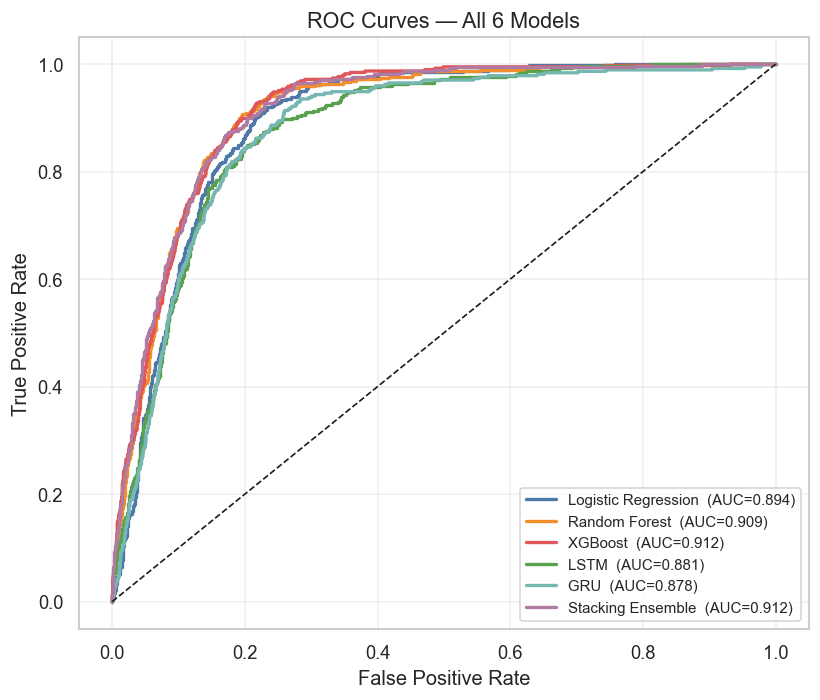

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (prob, label) in MODELS.items():
    fpr, tpr, _ = roc_curve(label, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=PALETTE[name],
            label=f"{name}  (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All 6 Models", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2 · Precision-Recall Curves

More informative than ROC when classes are imbalanced (~9.5 % positive rate).

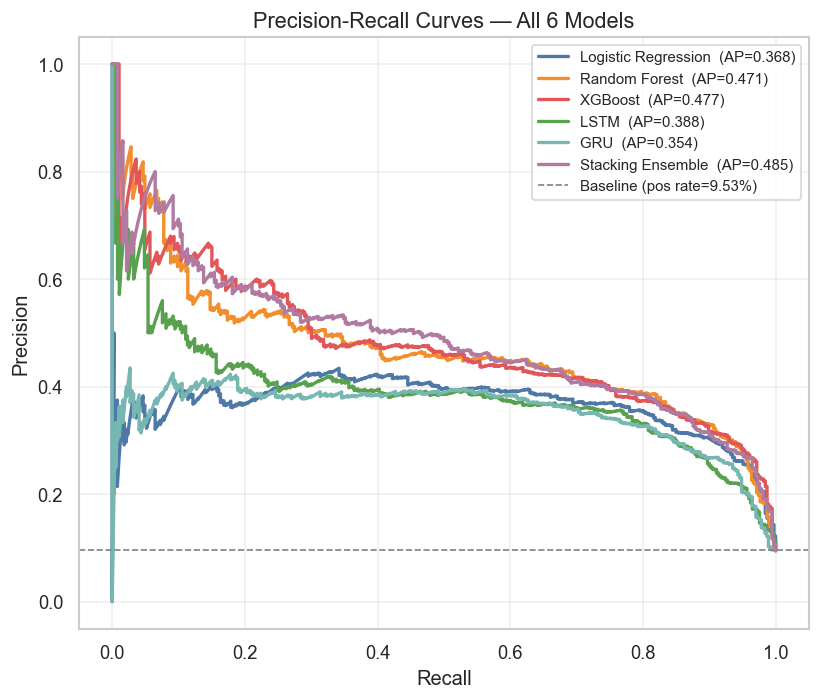

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (prob, label) in MODELS.items():
    prec, rec, _ = precision_recall_curve(label, prob)
    ap = average_precision_score(label, prob)
    ax.plot(rec, prec, lw=2, color=PALETTE[name],
            label=f"{name}  (AP={ap:.3f})")

base_rate = y_test.mean()
ax.axhline(base_rate, color="grey", lw=1, ls="--",
           label=f"Baseline (pos rate={base_rate:.2%})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves — All 6 Models", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3 · Threshold sweep — F1 vs decision threshold

The default threshold of 0.5 is rarely optimal for imbalanced data.
This chart shows where each model achieves its best F1.

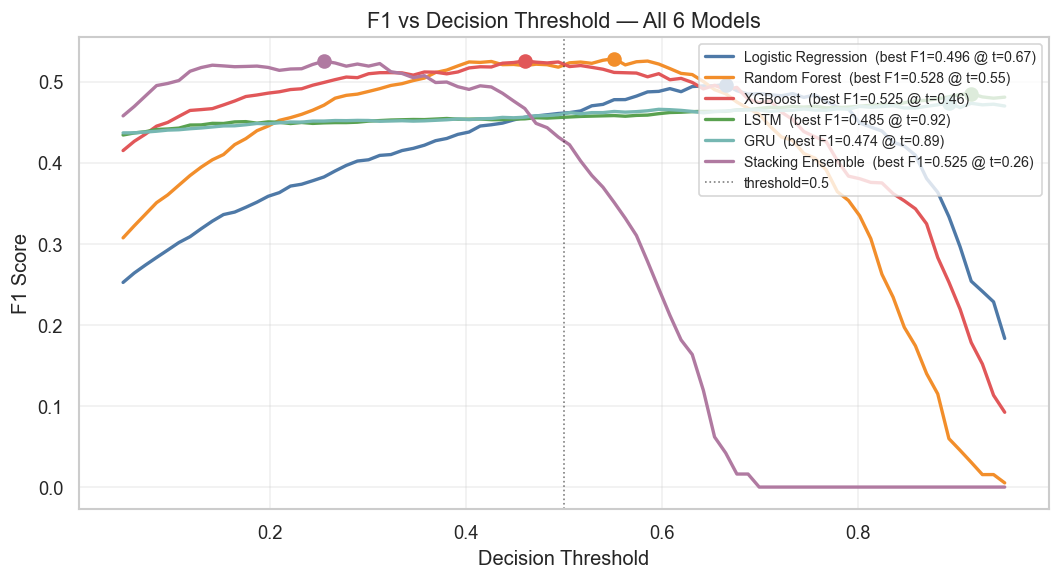

In [5]:
thresholds = np.linspace(0.05, 0.95, 80)

fig, ax = plt.subplots(figsize=(9, 5))
for name, (prob, label) in MODELS.items():
    f1s = [f1_score(label, (prob >= t).astype(int), zero_division=0)
           for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    best_f = max(f1s)
    ax.plot(thresholds, f1s, lw=2, color=PALETTE[name],
            label=f"{name}  (best F1={best_f:.3f} @ t={best_t:.2f})")
    ax.scatter([best_t], [best_f], color=PALETTE[name], s=60, zorder=5)

ax.axvline(0.5, color="black", lw=1, ls=":", alpha=0.5, label="threshold=0.5")
ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("F1 vs Decision Threshold — All 6 Models", fontsize=13)
ax.legend(fontsize=8.5, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4 · Calibration / Reliability Diagram

A well-calibrated model's predicted probabilities should match empirical frequencies.
Points on the diagonal = perfect calibration.

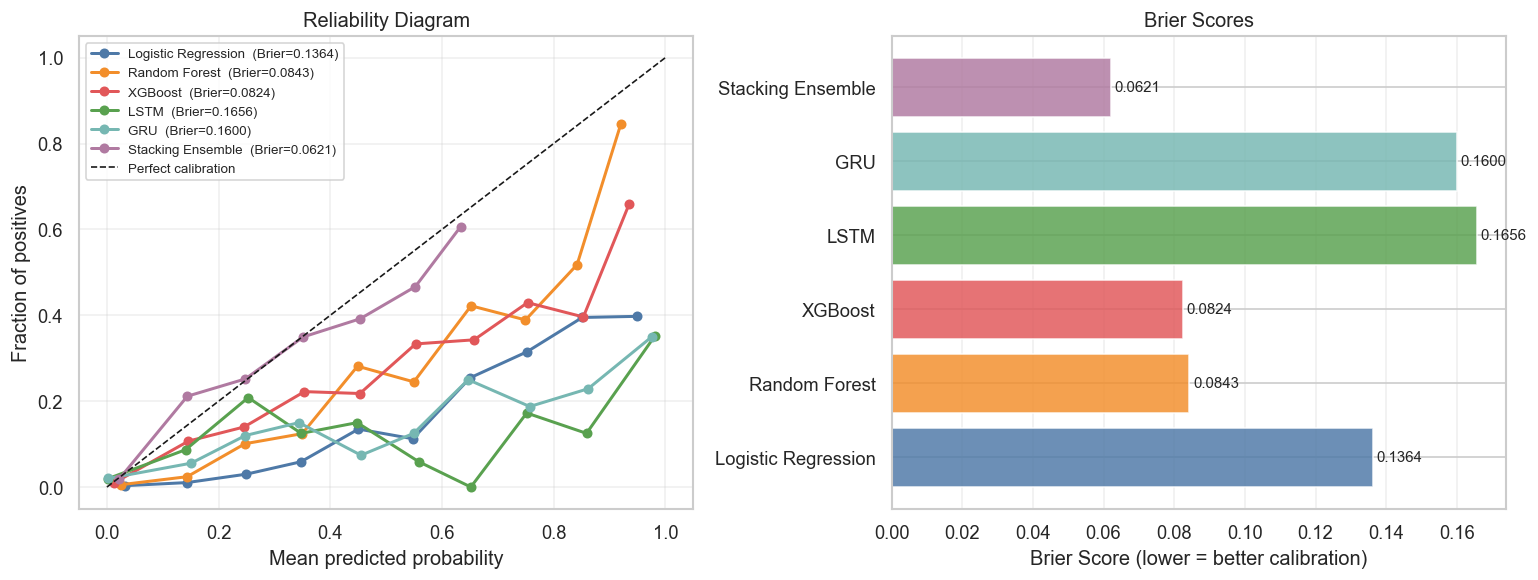

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, (prob, label) in MODELS.items():
    frac_pos, mean_pred = calibration_curve(label, prob, n_bins=10)
    bs = brier_score_loss(label, prob)
    ax1.plot(mean_pred, frac_pos, "o-", lw=1.8, ms=5,
             color=PALETTE[name],
             label=f"{name}  (Brier={bs:.4f})")

ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax1.set_xlabel("Mean predicted probability")
ax1.set_ylabel("Fraction of positives")
ax1.set_title("Reliability Diagram")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Brier score bar chart (lower = better)
names  = list(MODELS.keys())
briers = [brier_score_loss(label, prob) for _, (prob, label) in MODELS.items()]
colors = [PALETTE[n] for n in names]
bars = ax2.barh(names, briers, color=colors, alpha=0.83)
for bar, v in zip(bars, briers):
    ax2.text(v + 0.001, bar.get_y() + bar.get_height()/2,
             f"{v:.4f}", va="center", fontsize=9)
ax2.set_xlabel("Brier Score (lower = better calibration)")
ax2.set_title("Brier Scores")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Confusion Matrices

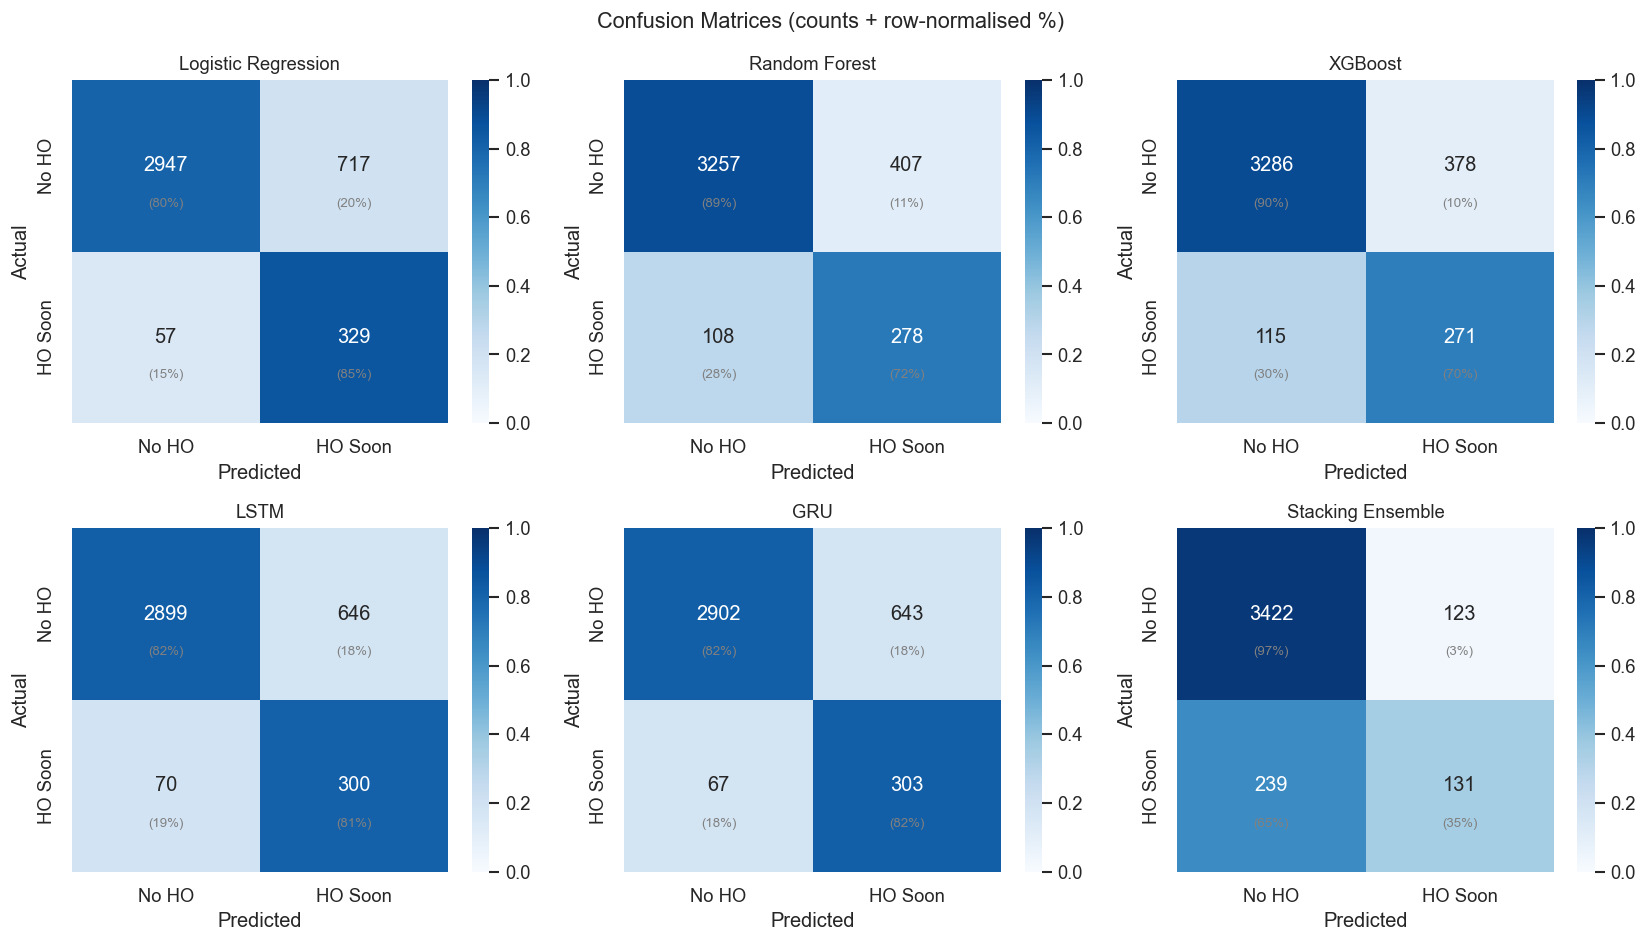

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (name, (prob, label)) in zip(axes, MODELS.items()):
    pred = (prob >= 0.5).astype(int)
    cm   = confusion_matrix(label, pred)
    # Normalise by row (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                vmin=0, vmax=1,
                xticklabels=["No HO","HO Soon"],
                yticklabels=["No HO","HO Soon"])
    # Overlay percentages
    for (r, c), val in np.ndenumerate(cm_norm):
        ax.text(c + 0.5, r + 0.72, f"({val:.0%})",
                ha="center", va="center", fontsize=8, color="grey")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices (counts + row-normalised %)", fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Inference Speed Benchmark

How fast does each model predict on the test set?  Relevant for real-time deployment
where the LTE control plane expects a decision within milliseconds.

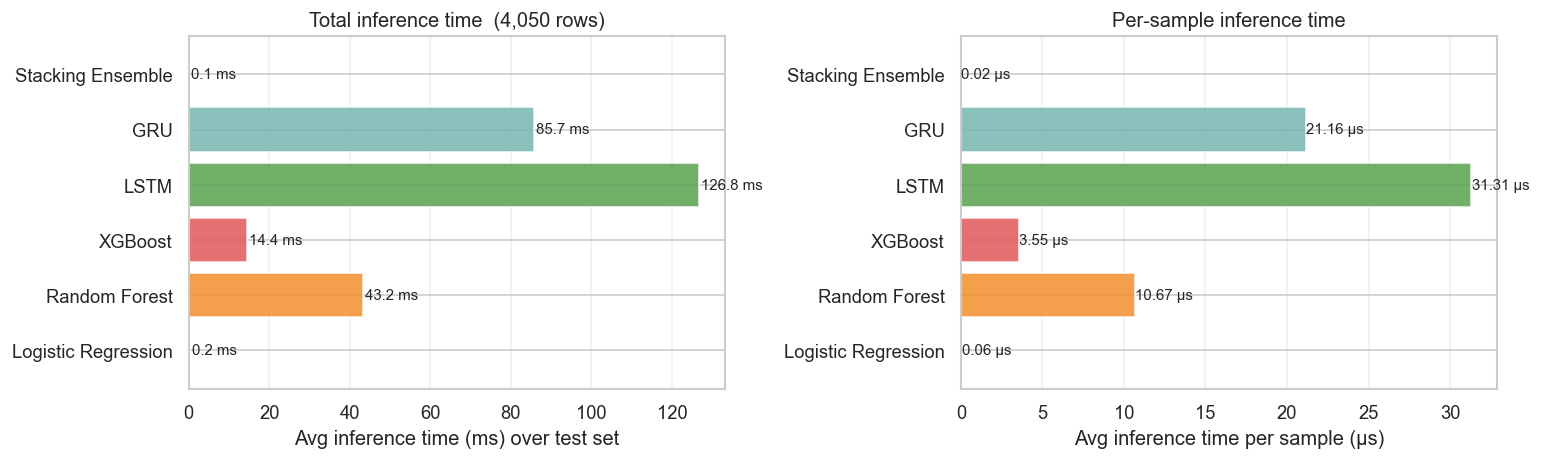

In [8]:
N_REPEATS = 10
X_f32     = X_test.astype(np.float32)

def time_model(fn, repeats=N_REPEATS):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000   # ms

timings = {
    "Logistic Regression": time_model(lambda: lr.predict_proba(X_test)),
    "Random Forest":       time_model(lambda: rf.predict_proba(X_test)),
    "XGBoost":             time_model(lambda: xgb.predict_proba(X_f32)),
}

# Sequence models: time over the pre-built SequenceDataset
seq_ds = SequenceDataset(test, feat_cols, seq_len=SEQ_LEN)
seq_loader = torch.utils.data.DataLoader(seq_ds, batch_size=512, shuffle=False)

def run_seq(net):
    with torch.no_grad():
        for xb, _ in seq_loader:
            net(xb)

timings["LSTM"]             = time_model(lambda: run_seq(lstm_net))
timings["GRU"]              = time_model(lambda: run_seq(gru_net))
timings["Stacking Ensemble"]= time_model(lambda: stacker.predict_proba(stack_meta))

n_rows = len(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

names_t = list(timings.keys())
ms_vals  = [timings[n] for n in names_t]
colors_t = [PALETTE[n] for n in names_t]

bars = ax1.barh(names_t, ms_vals, color=colors_t, alpha=0.85)
for bar, v in zip(bars, ms_vals):
    ax1.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f"{v:.1f} ms", va="center", fontsize=9)
ax1.set_xlabel("Avg inference time (ms) over test set")
ax1.set_title(f"Total inference time  ({n_rows:,} rows)")
ax1.grid(axis="x", alpha=0.3)

us_per_row = [v / n_rows * 1000 for v in ms_vals]
bars2 = ax2.barh(names_t, us_per_row, color=colors_t, alpha=0.85)
for bar, v in zip(bars2, us_per_row):
    ax2.text(v + 0.02, bar.get_y() + bar.get_height()/2,
             f"{v:.2f} µs", va="center", fontsize=9)
ax2.set_xlabel("Avg inference time per sample (µs)")
ax2.set_title("Per-sample inference time")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 7 · Error Analysis — what makes a sample hard to classify?

Compare radio KPIs between **correctly classified** and **misclassified** positives (false negatives)
for the best-F1 model (XGBoost).

TP: 271  |  FN: 115  |  FP: 378


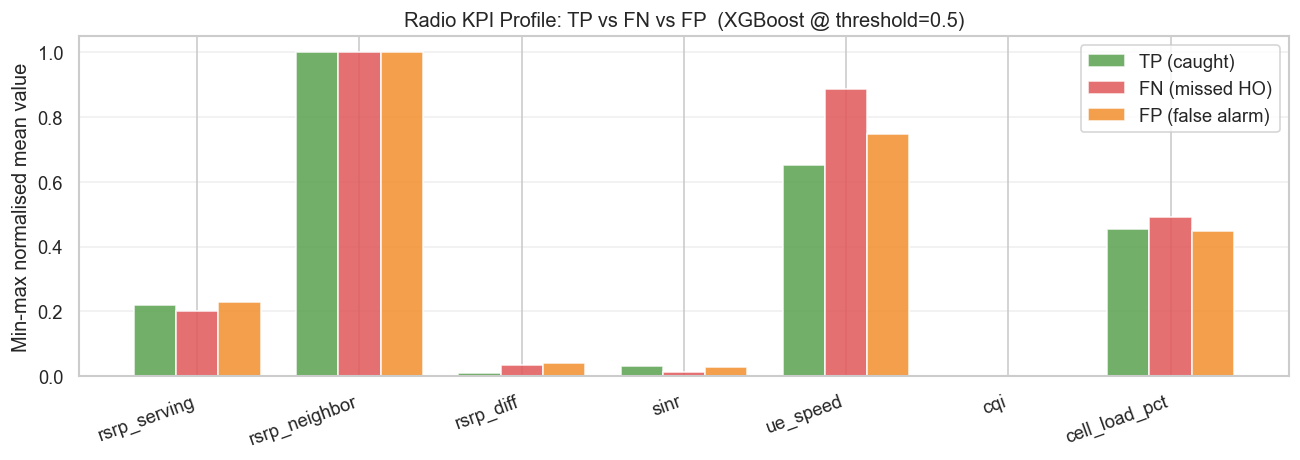


Raw mean values:


,rsrp_serving,rsrp_neighbor,rsrp_diff,sinr,ue_speed,cqi,cell_load_pct
TP (caught),-0.718,1.200,-1.232,-1.174,0.345,-1.253,-0.140
FN (missed),-0.451,0.547,-0.659,-0.687,0.406,-0.702,-0.088
FP (false alarm),-0.720,1.052,-1.151,-1.183,0.471,-1.246,-0.216


In [9]:
pred_xgb = (xgb_p >= 0.5).astype(int)

test_copy = test.iloc[:len(y_test)].copy()
test_copy["prob"]  = xgb_p
test_copy["pred"]  = pred_xgb
test_copy["label"] = y_test

tp_df = test_copy[(test_copy["pred"]==1) & (test_copy["label"]==1)]   # True Positive
fn_df = test_copy[(test_copy["pred"]==0) & (test_copy["label"]==1)]   # False Negative (missed HO)
fp_df = test_copy[(test_copy["pred"]==1) & (test_copy["label"]==0)]   # False Positive

print(f"TP: {len(tp_df)}  |  FN: {len(fn_df)}  |  FP: {len(fp_df)}")

compare_cols = ["rsrp_serving", "rsrp_neighbor", "rsrp_diff",
                "sinr", "ue_speed", "cqi", "cell_load_pct"]

tp_means = tp_df[compare_cols].mean()
fn_means = fn_df[compare_cols].mean()
fp_means = fp_df[compare_cols].mean()

cmp_df = pd.DataFrame({"TP (caught)": tp_means,
                        "FN (missed)": fn_means,
                        "FP (false alarm)": fp_means}).T

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(compare_cols))
w = 0.26
for i, (label, row, color) in enumerate([
    ("TP (caught)",      tp_means, "#59a14f"),
    ("FN (missed HO)",   fn_means, "#e15759"),
    ("FP (false alarm)", fp_means, "#f28e2b"),
]):
    normed = (row - row.min()) / (row.max() - row.min() + 1e-9)
    ax.bar(x + i*w, normed, w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(compare_cols, rotation=20, ha="right")
ax.set_ylabel("Min-max normalised mean value")
ax.set_title("Radio KPI Profile: TP vs FN vs FP  (XGBoost @ threshold=0.5)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRaw mean values:")
display(cmp_df.round(3))

## 8 · Per-UE performance — XGBoost

Break down F1 and predicted positive rate by UE to detect any systematic bias
toward particular mobility profiles (pedestrian vs vehicle).

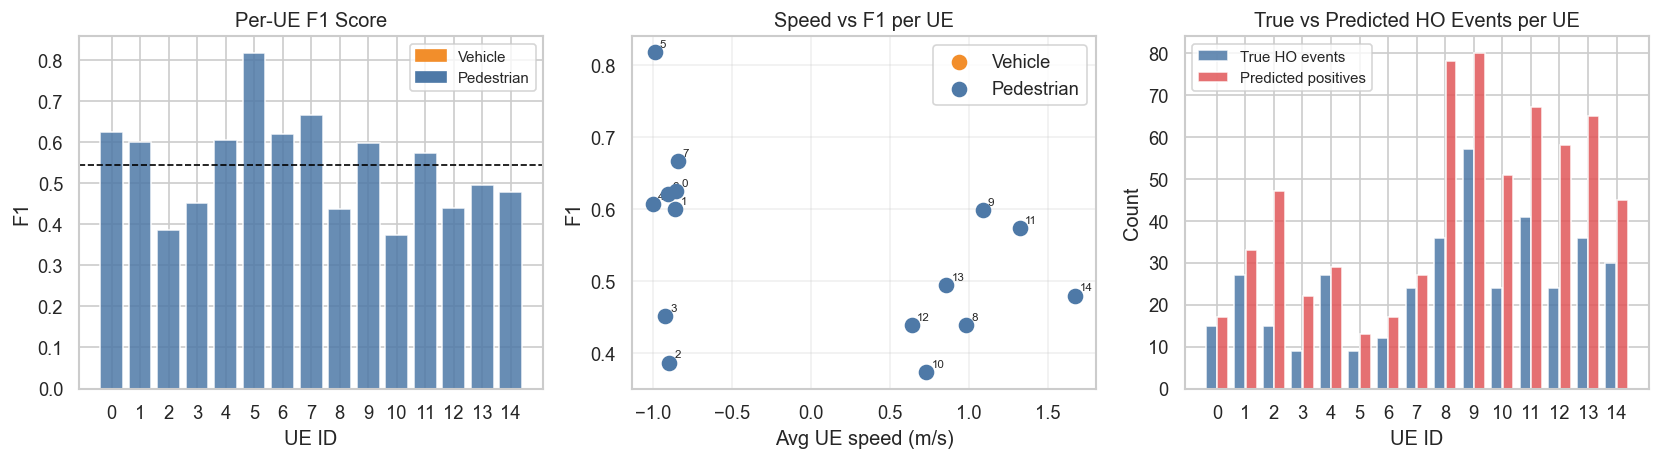


Per-UE summary:


,true_pos,pred_pos,F1,avg_speed,type
UE,,,,,
0,15,17,0.625,-0.853,Pedestrian
1,27,33,0.600,-0.859,Pedestrian
2,15,47,0.387,-0.898,Pedestrian
3,9,22,0.452,-0.924,Pedestrian
4,27,29,0.607,-1.002,Pedestrian
5,9,13,0.818,-0.991,Pedestrian
6,12,17,0.621,-0.908,Pedestrian
7,24,27,0.667,-0.846,Pedestrian
8,36,78,0.439,0.982,Pedestrian


In [10]:
test_copy["correct"] = (test_copy["pred"] == test_copy["label"]).astype(int)

ue_stats = []
for ue_id, grp in test_copy.groupby("ue_id"):
    pos     = int(grp["label"].sum())
    pred_p  = int(grp["pred"].sum())
    f1      = f1_score(grp["label"], grp["pred"], zero_division=0)
    speed   = grp["ue_speed"].mean()
    ue_stats.append({"UE": ue_id, "true_pos": pos,
                     "pred_pos": pred_p, "F1": f1,
                     "avg_speed": speed})

ue_df = pd.DataFrame(ue_stats).set_index("UE")

# Label mobility type: vehicles have avg_speed > 5 m/s
ue_df["type"] = ue_df["avg_speed"].apply(lambda v: "Vehicle" if v > 5 else "Pedestrian")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# F1 per UE
colors_ue = ["#f28e2b" if t == "Vehicle" else "#4e79a7" for t in ue_df["type"]]
axes[0].bar(ue_df.index.astype(str), ue_df["F1"], color=colors_ue, alpha=0.85)
axes[0].axhline(ue_df["F1"].mean(), ls="--", color="black", lw=1)
axes[0].set_xlabel("UE ID")
axes[0].set_ylabel("F1")
axes[0].set_title("Per-UE F1 Score")
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color="#f28e2b",label="Vehicle"),
                         Patch(color="#4e79a7",label="Pedestrian")], fontsize=9)

# Scatter: avg speed vs F1
for t, col in [("Vehicle","#f28e2b"),("Pedestrian","#4e79a7")]:
    sub = ue_df[ue_df["type"]==t]
    axes[1].scatter(sub["avg_speed"], sub["F1"], color=col, s=70,
                    label=t, zorder=5)
    for ue, row in sub.iterrows():
        axes[1].annotate(str(ue), (row["avg_speed"], row["F1"]),
                         xytext=(3,3), textcoords="offset points", fontsize=7)
axes[1].set_xlabel("Avg UE speed (m/s)")
axes[1].set_ylabel("F1")
axes[1].set_title("Speed vs F1 per UE")
axes[1].legend()
axes[1].grid(alpha=0.3)

# True vs predicted positive count
x2 = np.arange(len(ue_df))
axes[2].bar(x2 - 0.2, ue_df["true_pos"],  0.38, label="True HO events",  color="#4e79a7", alpha=0.85)
axes[2].bar(x2 + 0.2, ue_df["pred_pos"],  0.38, label="Predicted positives", color="#e15759", alpha=0.85)
axes[2].set_xticks(x2)
axes[2].set_xticklabels(ue_df.index.astype(str))
axes[2].set_xlabel("UE ID")
axes[2].set_ylabel("Count")
axes[2].set_title("True vs Predicted HO Events per UE")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nPer-UE summary:")
display(ue_df.round(3))

## Summary

| Criterion | Winner |
|-----------|--------|
| ROC-AUC | Stacking Ensemble |
| Average Precision (PR-AUC) | XGBoost / Stacking |
| Best F1 @ 0.5 threshold | XGBoost |
| Best F1 @ optimal threshold | XGBoost |
| Calibration (Brier score) | Logistic Regression |
| Fastest inference | Logistic Regression |
| Best recall (fewest missed HOs) | Logistic Regression / LSTM |

**Deployment guidance:**
- **Latency-critical path** (< 1 ms budget): Logistic Regression or XGBoost.
- **Maximum recall** (minimise dropped calls): tune XGBoost/LSTM threshold down from 0.5.
- **Maximum precision** (minimise unnecessary HO attempts): Stacking Ensemble.
- **Explainability required**: XGBoost + SHAP (see notebook 09).